Raw time-series data saved to 'simulated_ppg_timeseries_data.csv'
Aggregated subject-level data saved to 'simulated_ppg_subject_data.csv'
Windowed PPG data saved to 'X_ppg_windows.npy' with shape: (450, 2000, 1)
Hydration labels saved to 'y_hydration.npy' with shape: (450,)


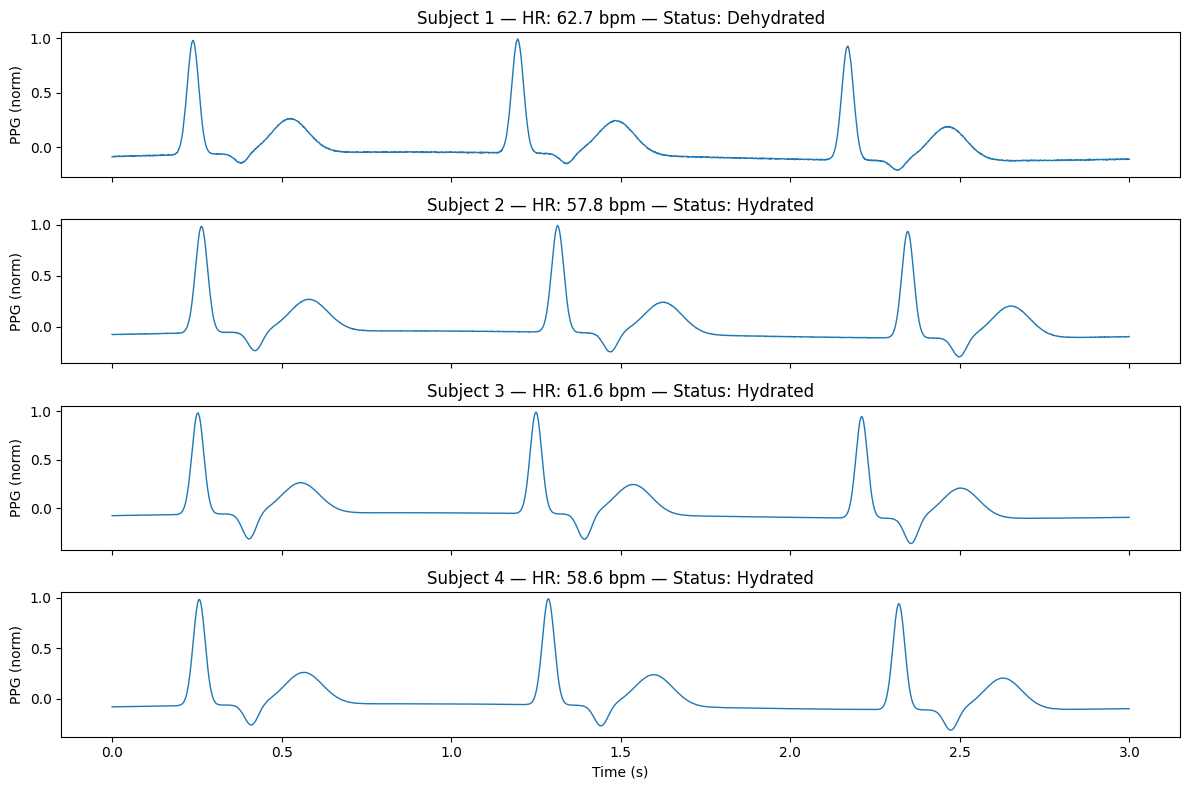

In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -------------------------------------------------------------------
# Reproducibility
# -------------------------------------------------------------------
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# -------------------------------------------------------------------
# Global parameters
# -------------------------------------------------------------------
num_subjects = 50        # You can increase later (50, 100, etc.)
sampling_rate = 1000     # Hz
duration = 10            # seconds
num_samples = sampling_rate * duration

# Time vector
time = np.linspace(0, duration, num_samples)

# Windowing parameters for CNN
window_seconds = 2.0
step_seconds = 1.0
window_size = int(window_seconds * sampling_rate)
step_size = int(step_seconds * sampling_rate)

# -------------------------------------------------------------------
# Helper: simulate a realistic PPG waveform with HRV + dicrotic notch
# -------------------------------------------------------------------
def simulate_ppg(
    hr,
    time,
    noise_level=0.01,
    base_amplitude=1.0,
    hrv_std_frac=0.02,
    notch_depth=0.15,
):
    """
    Generate a realistic synthetic PPG waveform with:
      - Systolic + diastolic peaks
      - Dicrotic notch as a negative deflection
      - Baseline drift
      - Gaussian noise
      - Beat-to-beat HR variability (HRV)
    hr           : mean heart rate (bpm)
    base_amplitude : overall pulse amplitude scaling
    notch_depth  : positive scalar controlling how deep the notch is
                   (hydrated => larger, dehydrated => smaller)
    """
    t = time
    ppg = np.zeros_like(t)

    mean_period = 60.0 / hr  # seconds per beat
    beat_start = 0.0

    while beat_start < t[-1] + mean_period:
        # Beat-to-beat variability
        period = mean_period * (1.0 + np.random.normal(0.0, hrv_std_frac))
        if period <= 0:
            period = mean_period

        beat_mask = (t >= beat_start) & (t < beat_start + period)
        beat_t = t[beat_mask] - beat_start

        if beat_t.size > 0:
            # Systolic peak (sharp, early)
            systolic = systolic = np.exp(-((beat_t - 0.25 * period) ** 2) / (0.0006 * period))

            # Diastolic wave (broader, later)
            diastolic =  diastolic = 0.3 * np.exp(-((beat_t - 0.55 * period) ** 2) / (0.006 * period))

            # Dicrotic notch: downward dip after systole, before full diastole
            # notch_depth is positive; we apply it as a negative Gaussian
            notch = -notch_depth * np.exp(-((beat_t - 0.40 * period) ** 2) / (0.0008 * period))

            pulse = base_amplitude * (systolic + diastolic + notch)
            ppg[beat_mask] += pulse

        beat_start += period

    # Baseline drift (e.g., respiration)
    drift = 0.03 * np.sin(2 * np.pi * 0.3 * t)  # ~0.3 Hz baseline drift

    # Add noise + drift
    ppg += drift + noise_level * np.random.normal(0, 0.2, len(t))

    # Normalize to zero-mean and scale to [-1, 1]
    ppg = ppg - np.mean(ppg)
    max_abs = np.max(np.abs(ppg))
    if max_abs > 0:
        ppg = ppg / max_abs
    else:
        ppg = np.zeros_like(ppg)

    return ppg

def create_windows(signal, window_size, step_size):

    windows = []
    for start in range(0, len(signal) - window_size + 1, step_size):
        win = signal[start:start + window_size]
        windows.append(win)
    return windows


labels = ['Hydrated'] * (num_subjects // 2) + \
         ['Dehydrated'] * (num_subjects - num_subjects // 2)
random.shuffle(labels)

# Containers
records = []
subject_metadata = []
all_windows = []
all_labels = []

hydration_to_int = {'Hydrated': 1, 'Dehydrated': 0}


for subject_id, hydration_status in enumerate(labels, start=1):
    # Demographics
    age = random.randint(18, 75)
    sex = random.choice(['Male', 'Female'])
    monk_skin_tone = random.randint(1, 10)      # 1 = light, 10 = dark
    workouts_per_week = random.randint(0, 7)

    # Base heart rate for this subject
    base_hr = random.gauss(70, 8)

    # Modify HR by hydration status
    if hydration_status == 'Hydrated':
        heart_rate = base_hr + random.gauss(-10, 5)
    else:
        heart_rate = base_hr + random.gauss(+10, 5)

    # Clamp HR
    heart_rate = max(45, min(120, heart_rate))

    # Base noise as function of skin tone and fitness
    noise_level = 0.005 + 0.003 * (monk_skin_tone / 10.0) - 0.001 * workouts_per_week
    noise_level = max(noise_level, 0.001)

    # Base amplitude vs skin tone
    amplitude = 1.0 - 0.2 * (monk_skin_tone / 10.0)

    # Hydration-specific tweaks:
    # - Hydrated: slightly cleaner + larger amplitude + deeper notch
    # - Dehydrated: noisier, smaller amplitude, shallower notch
    if hydration_status == 'Hydrated':
        noise_level *= 0.9
        amplitude *= 1.10
        notch_depth = 0.20 + np.random.normal(0, 0.04)  # stronger notch
    else:
        noise_level *= 1.3
        amplitude *= 0.90
        notch_depth = 0.08 + np.random.normal(0, 0.02)  # weaker notch


    notch_depth = float(max(0.02, min(0.30, notch_depth)))

    # Generate PPG signal
    ppg_signal = simulate_ppg(
        hr=heart_rate,
        time=time,
        noise_level=noise_level,
        base_amplitude=amplitude,
        hrv_std_frac=0.02,
        notch_depth=notch_depth
    )


    for t_val, ppg_val in zip(time, ppg_signal):
        records.append({
            'subject_id': subject_id,
            'time': t_val,
            'ppg_signal': ppg_val,
            'age': age,
            'sex': sex,
            'monk_skin_tone': monk_skin_tone,
            'workouts_per_week': workouts_per_week,
            'heart_rate': heart_rate,
            'hydration_status': hydration_status
        })

    # Subject-level metadata
    subject_metadata.append({
        'subject_id': subject_id,
        'age': age,
        'sex': sex,
        'monk_skin_tone': monk_skin_tone,
        'workouts_per_week': workouts_per_week,
        'heart_rate': heart_rate,
        'hydration_status': hydration_status,
        'noise_level_used': noise_level,
        'amplitude_used': amplitude,
        'notch_depth_used': notch_depth
    })


    subject_windows = create_windows(
        signal=ppg_signal,
        window_size=window_size,
        step_size=step_size
    )

    for w in subject_windows:
        all_windows.append(w)
        all_labels.append(hydration_to_int[hydration_status])


df = pd.DataFrame(records)
subject_df = pd.DataFrame(subject_metadata)

df.to_csv('simulated_ppg_timeseries_data.csv', index=False)
subject_df.to_csv('simulated_ppg_subject_data.csv', index=False)

print("Raw time-series data saved to 'simulated_ppg_timeseries_data.csv'")
print("Aggregated subject-level data saved to 'simulated_ppg_subject_data.csv'")


X = np.stack(all_windows, axis=0)  # (n_windows, window_size)
y = np.array(all_labels)           # (n_windows,)

# Add channel dimension for Conv1D
X = X[..., np.newaxis]             # (n_windows, window_size, 1)

np.save('X_ppg_windows.npy', X)
np.save('y_hydration.npy', y)

print("Windowed PPG data saved to 'X_ppg_windows.npy' with shape:", X.shape)
print("Hydration labels saved to 'y_hydration.npy' with shape:", y.shape)


# Plot first 4 subjects, first 3s
unique_subjects = df['subject_id'].unique()
n_plot = min(4, len(unique_subjects))

fig, axs = plt.subplots(n_plot, 1, figsize=(12, 8), sharex=True)
for i, subject_id in enumerate(unique_subjects[:n_plot]):
    sdata = df[(df['subject_id'] == subject_id) & (df['time'] <= 3.0)]
    axs[i].plot(sdata['time'], sdata['ppg_signal'], lw=1.0)
    axs[i].set_title(
        f"Subject {subject_id} — HR: {sdata['heart_rate'].iloc[0]:.1f} bpm "
        f"— Status: {sdata['hydration_status'].iloc[0]}"
    )
    axs[i].set_ylabel("PPG (norm)")
axs[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()




Saved simulated_ppg_timeseries_data.csv and simulated_ppg_subject_data.csv
X shape: (180, 2000, 1)
y shape: (180,)
Class balance: {np.int64(0): 90, np.int64(1): 90}
Train: (144, 2000, 1) Val: (36, 2000, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 2000, 32)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1000, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1000, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 500, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 500, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_dense (Dense)         │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,585 (170.25 KB)

 Trainable params: 43,585 (170.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step - accuracy: 0.4961 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 2/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.4705 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 3/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - accuracy: 0.4961 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 4/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.4948 - loss: 0.6940
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.4961 - loss: 0.6939 - val_accuracy: 0.5000 - val_loss: 0.6934 - learning_rate: 0.0010
Epoch 5/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - accuracy: 0.4961 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6936 - learning_rate: 5.0000e-04
Epoch 6/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - accuracy: 0.4961 - loss: 0.6936 - val_accurac

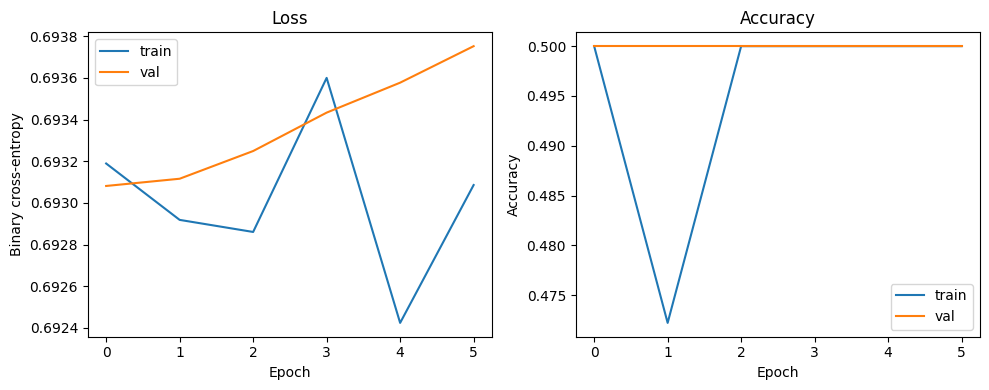

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

CNN-only validation accuracy: 0.5

CNN-only classification report:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        18
           1      0.500     1.000     0.667        18

    accuracy                          0.500        36
   macro avg      0.250     0.500     0.333        36
weighted avg      0.250     0.500     0.333        36

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Z_train shape: (144, 64)
Z_val shape: (36, 64)

CNN+GBM validation accuracy: 0.861

CNN+GBM classification report (0=Hydrated, 1=Dehydrated):
              precision    recall  f1-score   support

           0      0.882     0.833     0.857        18
           1      0.842     0.889     0.865        18

    accuracy                          0.861        36
   macro avg      0.862     0.861     0.861        36
weighted avg      0.862     0.861     0.861        36

CNN+GBM confusion matrix:
[[15  3]
 [ 2 16]]

Feature importances shape: (64,)


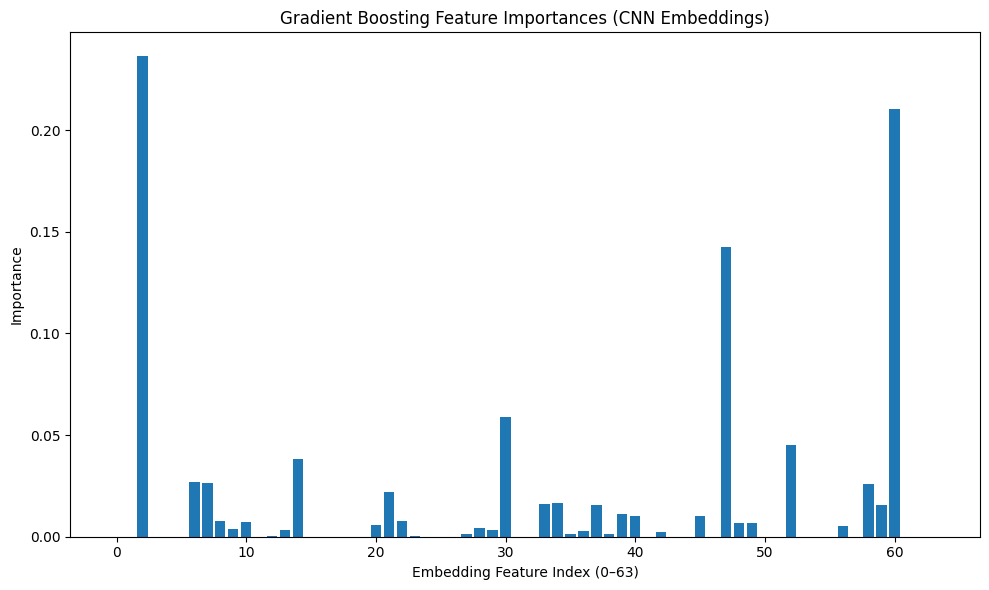


Top 10 most important embedding features:
  Feature 2: importance = 0.2362
  Feature 60: importance = 0.2103
  Feature 47: importance = 0.1426
  Feature 30: importance = 0.0590
  Feature 52: importance = 0.0450
  Feature 14: importance = 0.0382
  Feature 6: importance = 0.0269
  Feature 7: importance = 0.0266
  Feature 58: importance = 0.0257
  Feature 21: importance = 0.0222


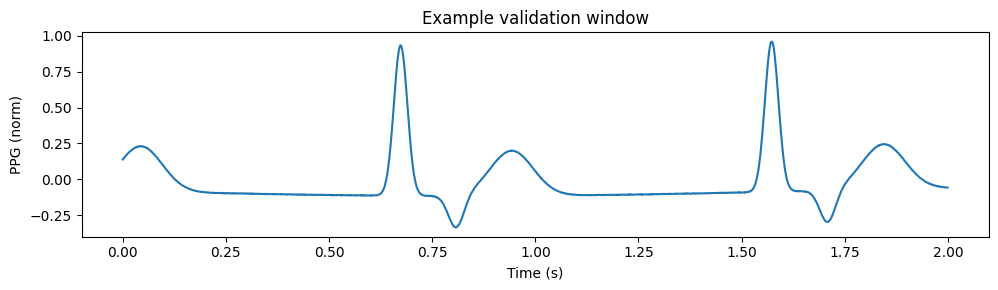


True label: 0 (0=Hydrated, 1=Dehydrated)
CNN prob (Dehydrated): 0.5033420324325562
CNN+GBM prob (Dehydrated): 0.34557058793600864
CNN+GBM pred: 0


In [ ]:
# ============================================================
# HYDRATION HYBRID PIPELINE: SIMULATION + CNN + GRADIENT BOOSTING
# ============================================================

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ------------------------------------------------------------
# 0. Reproducibility
# ------------------------------------------------------------
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# ------------------------------------------------------------
# 1. Simulation parameters
# ------------------------------------------------------------
num_subjects = 20        # bump later if you want (50, 100, ...)
sampling_rate = 1000     # Hz
duration = 10            # seconds
num_samples = sampling_rate * duration

time = np.linspace(0, duration, num_samples)

window_seconds = 2.0
step_seconds = 1.0
window_size = int(window_seconds * sampling_rate)
step_size = int(step_seconds * sampling_rate)

# ------------------------------------------------------------
# 2. PPG simulator with dicrotic notch & hydration effect
# ------------------------------------------------------------
def simulate_ppg(
    hr,
    time,
    noise_level=0.01,
    base_amplitude=1.0,
    hrv_std_frac=0.02,
    notch_depth=0.15,
):
    """
    Generate PPG with:
      - Systolic + diastolic peaks
      - Dicrotic notch (negative dip)
      - Baseline drift
      - Noise
      - HRV
    """
    t = time
    ppg = np.zeros_like(t)

    mean_period = 60.0 / hr
    beat_start = 0.0

    while beat_start < t[-1] + mean_period:
        period = mean_period * (1.0 + np.random.normal(0.0, hrv_std_frac))
        if period <= 0:
            period = mean_period

        mask = (t >= beat_start) & (t < beat_start + period)
        beat_t = t[mask] - beat_start

        if beat_t.size > 0:
            systolic = np.exp(-((beat_t - 0.25 * period) ** 2) / (0.0006 * period))
            diastolic = 0.3 * np.exp(-((beat_t - 0.55 * period) ** 2) / (0.006 * period))
            notch = -notch_depth * np.exp(
                -((beat_t - 0.40 * period) ** 2) / (0.0008 * period)
            )
            pulse = base_amplitude * (systolic + diastolic + notch)
            ppg[mask] += pulse

        beat_start += period

    drift = 0.03 * np.sin(2 * np.pi * 0.3 * t)
    ppg += drift + noise_level * np.random.normal(0, 0.2, len(t))

    # normalize to zero-mean, scale to [-1, 1]
    ppg -= np.mean(ppg)
    max_abs = np.max(np.abs(ppg))
    if max_abs > 0:
        ppg /= max_abs
    else:
        ppg = np.zeros_like(ppg)

    return ppg

def create_windows_1d(signal, window_size, step_size):
    windows = []
    for start in range(0, len(signal) - window_size + 1, step_size):
        win = signal[start:start + window_size]
        windows.append(win)
    return windows

# ------------------------------------------------------------
# 3. Simulate subjects and build dataset
# ------------------------------------------------------------
labels = ['Hydrated'] * (num_subjects // 2) + \
         ['Dehydrated'] * (num_subjects - num_subjects // 2)
random.shuffle(labels)

records = []
subject_metadata = []
all_windows = []
all_labels = []

hydration_to_int = {'Hydrated': 0, 'Dehydrated': 1}

for subject_id, hydration_status in enumerate(labels, start=1):
    age = random.randint(18, 75)
    sex = random.choice(['Male', 'Female'])
    monk_skin_tone = random.randint(1, 10)
    workouts_per_week = random.randint(0, 7)

    base_hr = random.gauss(70, 8)
    if hydration_status == 'Hydrated':
        heart_rate = base_hr + random.gauss(-5, 3)
    else:
        heart_rate = base_hr + random.gauss(+5, 3)
    heart_rate = max(45, min(120, heart_rate))

    noise_level = 0.005 + 0.003 * (monk_skin_tone / 10.0) - 0.001 * workouts_per_week
    noise_level = max(noise_level, 0.001)
    amplitude = 1.0 - 0.2 * (monk_skin_tone / 10.0)

    if hydration_status == 'Hydrated':
        noise_level *= 0.9
        amplitude *= 1.10
        notch_depth = 0.20 + np.random.normal(0, 0.02)
    else:
        noise_level *= 1.3
        amplitude *= 0.90
        notch_depth = 0.08 + np.random.normal(0, 0.02)

    notch_depth = float(max(0.02, min(0.30, notch_depth)))

    ppg_signal = simulate_ppg(
        hr=heart_rate,
        time=time,
        noise_level=noise_level,
        base_amplitude=amplitude,
        hrv_std_frac=0.02,
        notch_depth=notch_depth
    )

    for t_val, ppg_val in zip(time, ppg_signal):
        records.append({
            'subject_id': subject_id,
            'time': t_val,
            'ppg_signal': ppg_val,
            'age': age,
            'sex': sex,
            'monk_skin_tone': monk_skin_tone,
            'workouts_per_week': workouts_per_week,
            'heart_rate': heart_rate,
            'hydration_status': hydration_status
        })

    subject_metadata.append({
        'subject_id': subject_id,
        'age': age,
        'sex': sex,
        'monk_skin_tone': monk_skin_tone,
        'workouts_per_week': workouts_per_week,
        'heart_rate': heart_rate,
        'hydration_status': hydration_status,
        'noise_level_used': noise_level,
        'amplitude_used': amplitude,
        'notch_depth_used': notch_depth
    })

    # windowing for this subject
    win_list = create_windows_1d(ppg_signal, window_size, step_size)
    for w in win_list:
        all_windows.append(w)
        all_labels.append(hydration_to_int[hydration_status])

# build dataframes
df = pd.DataFrame(records)
subject_df = pd.DataFrame(subject_metadata)

df.to_csv('simulated_ppg_timeseries_data.csv', index=False)
subject_df.to_csv('simulated_ppg_subject_data.csv', index=False)

print("Saved simulated_ppg_timeseries_data.csv and simulated_ppg_subject_data.csv")

# build numpy arrays for CNN/GBM
X = np.stack(all_windows, axis=0)[..., np.newaxis]  # (n_windows, window_size, 1)
y = np.array(all_labels)

np.save('X_ppg_windows.npy', X)
np.save('y_hydration.npy', y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class balance:", {c: int((y == c).sum()) for c in np.unique(y)})

# ------------------------------------------------------------
# 4. Train/val split
# ------------------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Val:", X_val.shape)

# ------------------------------------------------------------
# 5. Build CNN (functional API)
# ------------------------------------------------------------
input_shape = X_train.shape[1:]  # (window_size, 1)

inputs = keras.Input(shape=input_shape)
x = layers.Conv1D(32, 7, padding='same', activation='relu')(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(64, 5, padding='same', activation='relu')(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(64, activation='relu', name='embedding_dense')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ------------------------------------------------------------
# 6. Plot CNN training curves
# ------------------------------------------------------------
def plot_training(history):
    hist = history.history
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(hist['loss'], label='train')
    plt.plot(hist['val_loss'], label='val')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Binary cross-entropy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist['accuracy'], label='train')
    plt.plot(hist['val_accuracy'], label='val')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training(history)

# quick CNN-only eval
val_probs_cnn = model.predict(X_val).flatten()
val_preds_cnn = (val_probs_cnn >= 0.5).astype(int)

print("\nCNN-only validation accuracy:",
      accuracy_score(y_val, val_preds_cnn))
print("\nCNN-only classification report:")
print(classification_report(y_val, val_preds_cnn, digits=3))

# ------------------------------------------------------------
# 7. Build feature extractor and get embeddings
# ------------------------------------------------------------
embedding_layer = model.get_layer('embedding_dense')
feature_extractor = keras.Model(
    inputs=model.input,
    outputs=embedding_layer.output
)

Z_train = feature_extractor.predict(X_train)
Z_val   = feature_extractor.predict(X_val)

print("Z_train shape:", Z_train.shape)  # (n_train, 64)
print("Z_val shape:", Z_val.shape)

# ------------------------------------------------------------
# 8. Gradient Boosting on embeddings
# ------------------------------------------------------------
gb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    ))
])

gb_pipe.fit(Z_train, y_train)
y_val_pred_gb = gb_pipe.predict(Z_val)
y_val_proba_gb = gb_pipe.predict_proba(Z_val)[:, 1]

acc_gb = accuracy_score(y_val, y_val_pred_gb)
print(f"\nCNN+GBM validation accuracy: {acc_gb:.3f}")

print("\nCNN+GBM classification report (0=Hydrated, 1=Dehydrated):")
print(classification_report(y_val, y_val_pred_gb, digits=3))

print("CNN+GBM confusion matrix:")
print(confusion_matrix(y_val, y_val_pred_gb))

# ------------------------------------------------------------
# 9. Feature importances from GBM
# ------------------------------------------------------------
gb = gb_pipe.named_steps['gb']
importances = gb.feature_importances_
print("\nFeature importances shape:", importances.shape)

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances)
plt.title("Gradient Boosting Feature Importances (CNN Embeddings)")
plt.xlabel("Embedding Feature Index (0–{})".format(len(importances)-1))
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

top_k = 10
idx_sorted = np.argsort(importances)[::-1]
print(f"\nTop {top_k} most important embedding features:")
for i in idx_sorted[:top_k]:
    print(f"  Feature {i}: importance = {importances[i]:.4f}")

# ------------------------------------------------------------
# 10. Helper functions for new data
# ------------------------------------------------------------
def predict_hydration_from_windows(X_new, feature_extractor, gb_pipe, threshold=0.5):
    """
    X_new: (n_windows, window_size, 1)
    Returns window-level preds and probs (Dehydrated probability).
    """
    Z_new = feature_extractor.predict(X_new)
    proba = gb_pipe.predict_proba(Z_new)[:, 1]
    preds = (proba >= threshold).astype(int)
    return preds, proba

def predict_hydration_from_raw_signal(
    ppg_signal,
    feature_extractor,
    gb_pipe,
    sampling_rate=1000,
    window_seconds=2.0,
    step_seconds=1.0,
    threshold=0.5
):
    """
    ppg_signal: 1D array (raw or preprocessed).
    Returns:
        subject_pred, subject_prob, window_preds, window_proba
    """
    ppg_signal = np.asarray(ppg_signal).flatten()
    window_size_local = int(window_seconds * sampling_rate)
    step_size_local = int(step_seconds * sampling_rate)

    wins = create_windows_1d(ppg_signal, window_size_local, step_size_local)
    if not wins:
        raise ValueError("Signal too short for given window/step settings.")

    X_new = np.stack(wins, axis=0)[..., np.newaxis]
    win_preds, win_proba = predict_hydration_from_windows(
        X_new, feature_extractor, gb_pipe, threshold=threshold
    )

    subject_prob = float(np.mean(win_proba))
    subject_pred = int(subject_prob >= threshold)
    return subject_pred, subject_prob, win_preds, win_proba

# ------------------------------------------------------------
# 11. Example: test hybrid predictor on one validation window
# ------------------------------------------------------------
import random as pyrand

idx = pyrand.randint(0, X_val.shape[0] - 1)
plt.figure(figsize=(10, 3))
plt.plot(np.arange(X_val.shape[1]) / sampling_rate, X_val[idx, :, 0])
plt.title("Example validation window")
plt.xlabel("Time (s)")
plt.ylabel("PPG (norm)")
plt.tight_layout()
plt.show()

print("\nTrue label:", y_val[idx], "(0=Hydrated, 1=Dehydrated)")
print("CNN prob (Dehydrated):", float(val_probs_cnn[idx]))
print("CNN+GBM prob (Dehydrated):", float(y_val_proba_gb[idx]))
print("CNN+GBM pred:", y_val_pred_gb[idx])
